# Multivariate EDA

Univariate analysis tells us about individual features. Multivariate EDA reveals *relationships* between features, and how features relate to the target variable.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
print("Shape:", df.shape)

Shape: (891, 15)


## Pair Plots — All Pairs at Once

A pair plot shows scatter plots for every pair of numerical features, with univariate histograms/KDE on the diagonal. Great for an initial survey of all pairwise relationships.

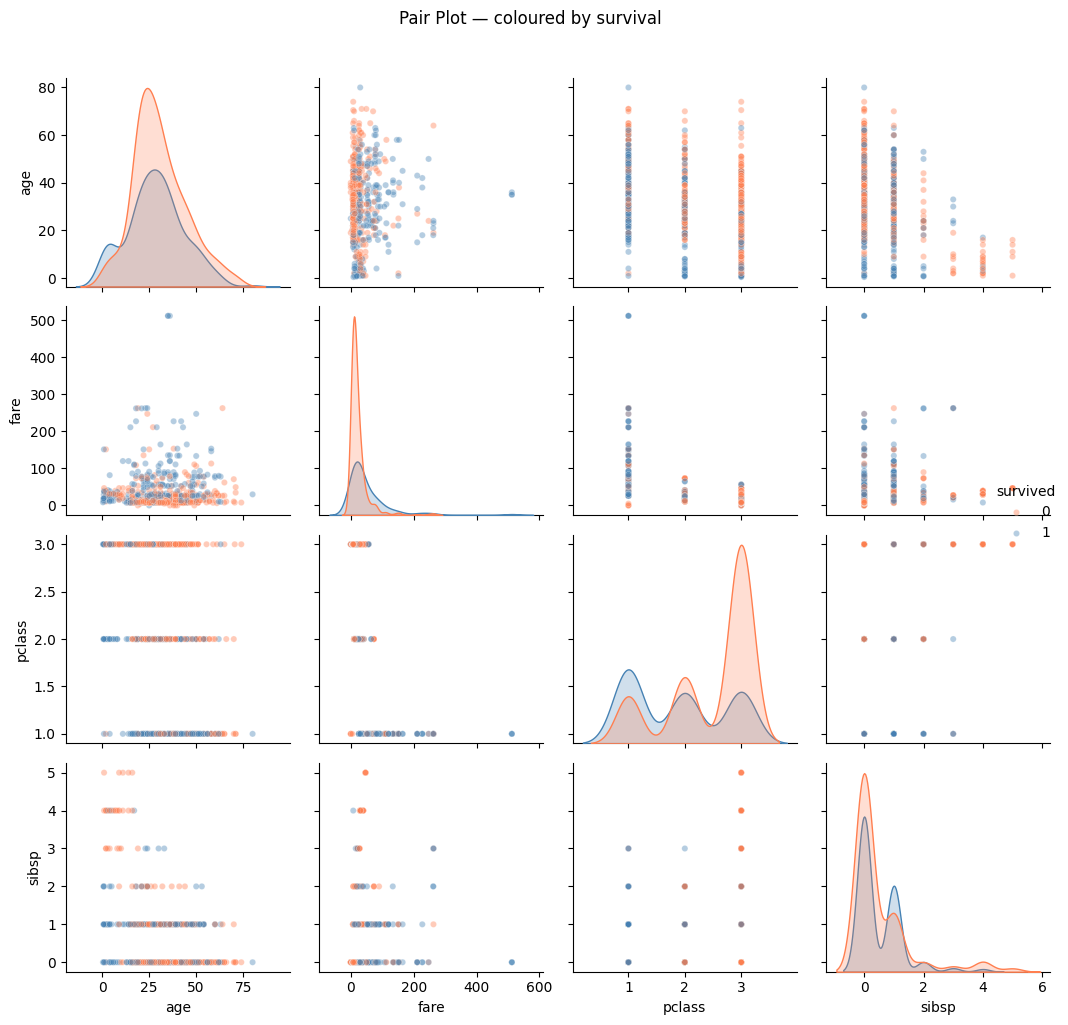

In [2]:
num_cols = ['age', 'fare', 'pclass', 'sibsp']
df_pair = df[num_cols + ['survived']].dropna()

g = sns.pairplot(
    df_pair,
    hue='survived',
    palette={0: 'coral', 1: 'steelblue'},
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20}
)
g.figure.suptitle('Pair Plot — coloured by survival', y=1.02)
plt.tight_layout()
plt.show()

---
## Numerical Feature vs Target

Use boxplots and violin plots to compare the distribution of a numerical feature across different target classes.

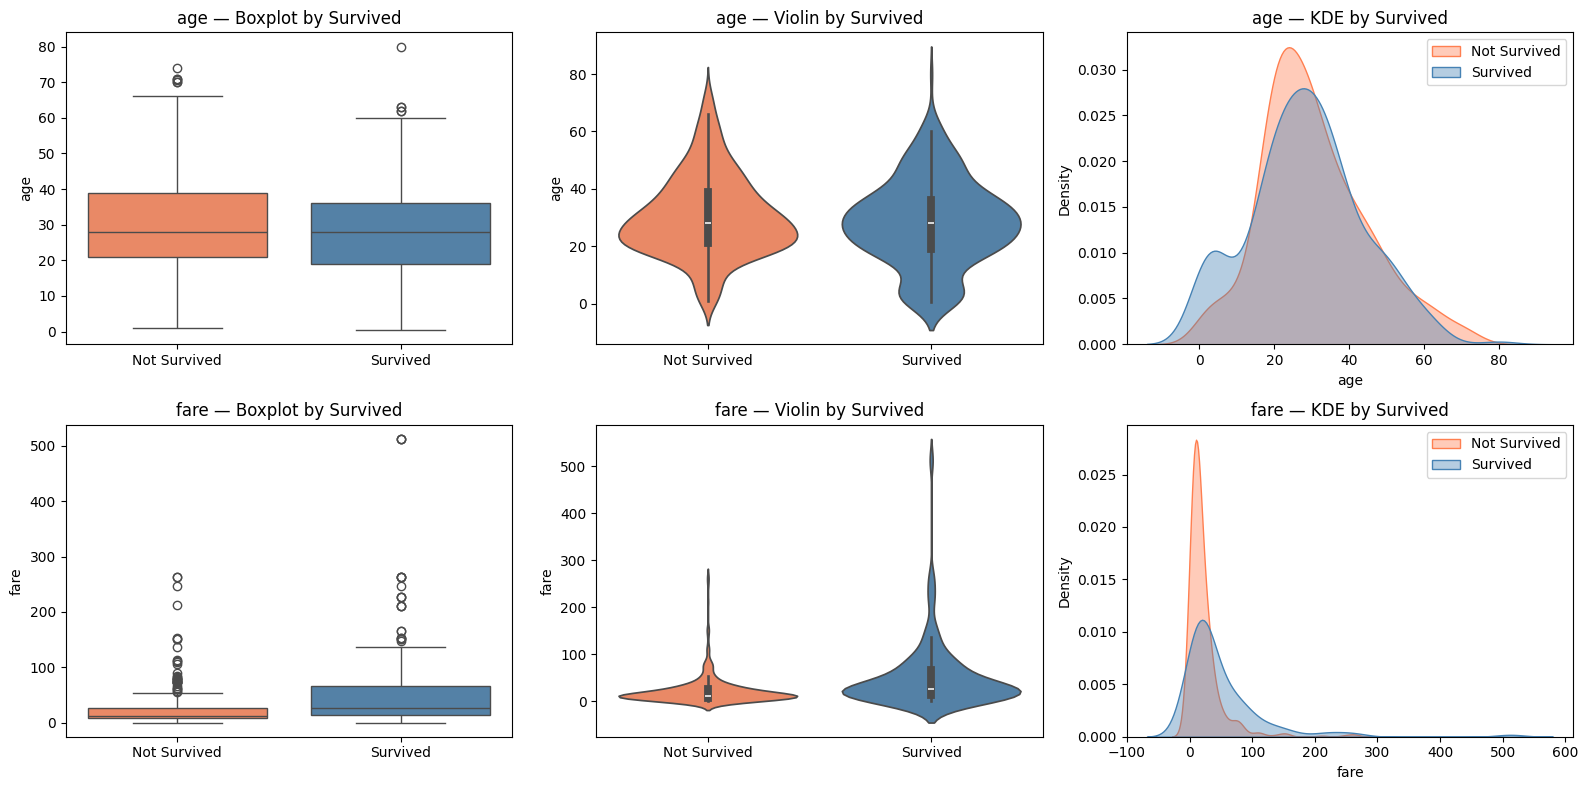

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
df_plot = df[['age', 'fare', 'pclass', 'survived']].dropna()
df_plot = df_plot.copy()
df_plot['survived_label'] = df_plot['survived'].map({0: 'Not Survived', 1: 'Survived'})

for col, row_axes in zip(['age', 'fare'], [axes[0], axes[1]]):
    palette = {'Not Survived': 'coral', 'Survived': 'steelblue'}

    # Boxplot
    sns.boxplot(x='survived_label', y=col, hue='survived_label',
                data=df_plot, palette=palette, ax=row_axes[0], legend=False)
    row_axes[0].set_title(f'{col} — Boxplot by Survived')
    row_axes[0].set_xlabel('')

    # Violin plot
    sns.violinplot(x='survived_label', y=col, hue='survived_label',
                   data=df_plot, palette=palette, inner='box',
                   ax=row_axes[1], legend=False)
    row_axes[1].set_title(f'{col} — Violin by Survived')
    row_axes[1].set_xlabel('')

    # KDE overlay
    for label, color in [('Not Survived', 'coral'), ('Survived', 'steelblue')]:
        subset = df_plot[df_plot['survived_label'] == label][col]
        sns.kdeplot(subset, ax=row_axes[2], color=color, fill=True, alpha=0.4, label=label)
    row_axes[2].set_title(f'{col} — KDE by Survived')
    row_axes[2].legend()

plt.tight_layout()
plt.show()

In [4]:
# Statistical summary by group
print("Mean values by survival:")
print(df[['age', 'fare', 'pclass', 'survived']].groupby('survived').mean().round(2))

Mean values by survival:
            age   fare  pclass
survived                      
0         30.63  22.12    2.53
1         28.34  48.40    1.95


---
## Categorical Feature vs Target

Use grouped bar charts or stacked proportion charts to see how survival rates differ across categories.

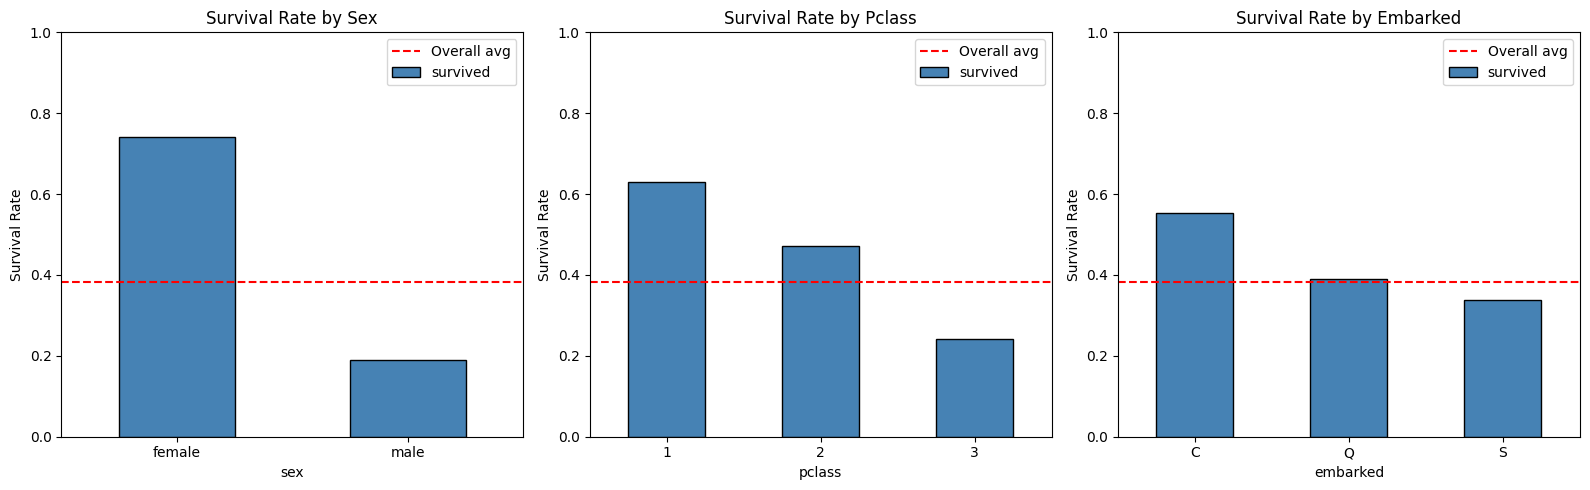

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['sex', 'pclass', 'embarked']):
    # Survival rate per category
    survival_rate = df.groupby(col)['survived'].mean().sort_values(ascending=False)
    survival_rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Survival Rate by {col.capitalize()}')
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1)
    ax.axhline(df['survived'].mean(), color='red', linestyle='--', label='Overall avg')
    ax.legend()
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

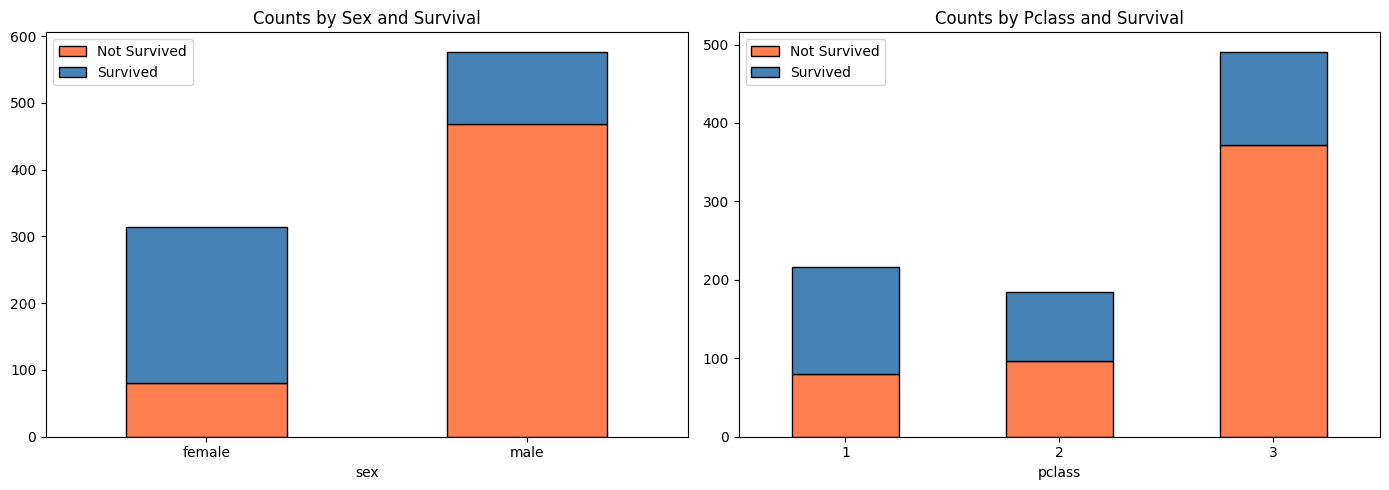

In [6]:
# Stacked count chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['sex', 'pclass']):
    ct = pd.crosstab(df[col], df['survived'])
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=['coral', 'steelblue'], edgecolor='black')
    ax.set_title(f'Counts by {col.capitalize()} and Survival')
    ax.legend(['Not Survived', 'Survived'])
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## Three-Variable Relationships

Use colour (hue) or faceting to add a third dimension to scatter plots.

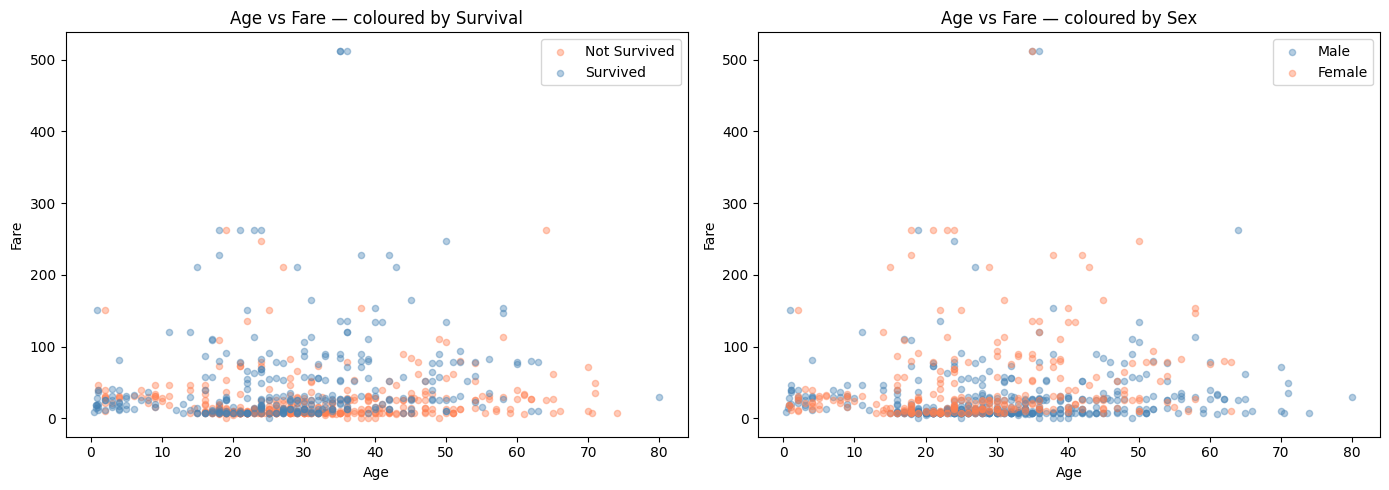

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot3 = df[['age', 'fare', 'sex', 'survived']].dropna()

# Age vs Fare, coloured by survival
for survived_val, color, label in [(0, 'coral', 'Not Survived'), (1, 'steelblue', 'Survived')]:
    sub = df_plot3[df_plot3['survived'] == survived_val]
    axes[0].scatter(sub['age'], sub['fare'], alpha=0.4, s=20, color=color, label=label)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Fare')
axes[0].set_title('Age vs Fare — coloured by Survival')
axes[0].legend()

# Age vs Fare, coloured by sex
for sex_val, color, label in [('male', 'steelblue', 'Male'), ('female', 'coral', 'Female')]:
    sub = df_plot3[df_plot3['sex'] == sex_val]
    axes[1].scatter(sub['age'], sub['fare'], alpha=0.4, s=20, color=color, label=label)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Fare')
axes[1].set_title('Age vs Fare — coloured by Sex')
axes[1].legend()

plt.tight_layout()
plt.show()

Survival rate by Sex × Class:
pclass      1      2      3
sex                        
female  0.968  0.921  0.500
male    0.369  0.157  0.135


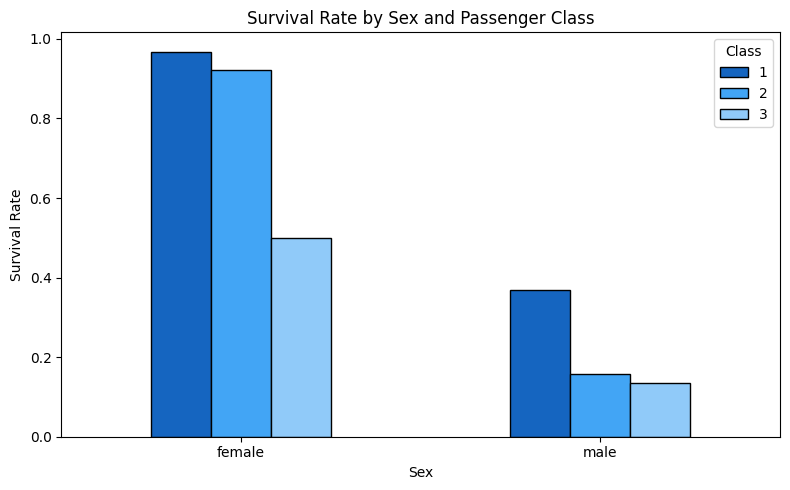

In [8]:
# Facet grid: survival rate by sex and class
pivot = df.groupby(['sex', 'pclass'])['survived'].mean().unstack()
print("Survival rate by Sex × Class:")
print(pivot.round(3))

pivot.plot(kind='bar', figsize=(8, 5), edgecolor='black', color=['#1565C0', '#42A5F5', '#90CAF9'])
plt.title('Survival Rate by Sex and Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Sex')
plt.xticks(rotation=0)
plt.legend(title='Class')
plt.tight_layout()
plt.show()

## Key Takeaways

| Question | Plot |
|---|---|
| All pairwise relationships? | Pair plot |
| Numerical feature vs target? | Boxplot, violin, KDE |
| Categorical feature vs target? | Bar chart of survival rates, crosstab |
| Three variables? | Scatter with hue, facet grid |

Multivariate EDA identifies the most predictive features *before* modelling — it guides feature selection and engineering.